# Introduction

This will be used to train the model (CYCLEGAN)

In [11]:
# !pip install torch torchvision  # (si besoin)
import os, random, math
import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# dénormaliser ([-1,1] -> [0,1]) pour l'affichage/sauvegarde
def denorm(x):
    return (x.clamp(-1,1) * 0.5) + 0.5


# DATALOADER

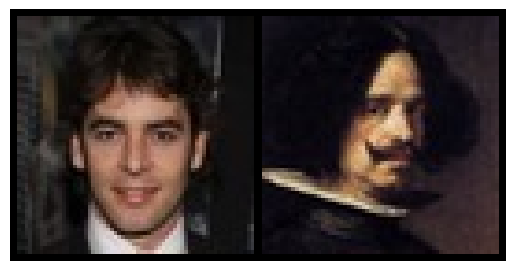

In [13]:
A_train_dir = "../../data/processed/64img_celeb/train"
A_test_dir  = "../../data/processed/64img_celeb/test"
B_train_dir = "../../data/processed/64paint_portrait/train"
B_test_dir  = "../../data/processed/64paint_portrait/test"

class UnpairedABDirs(Dataset):
    def __init__(self, dirA, dirB, train=True):
        self.A = [os.path.join(dirA,f) for f in os.listdir(dirA)
                  if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))]
        self.B = [os.path.join(dirB,f) for f in os.listdir(dirB)
                  if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))]
        self.t = (T.Compose([
                    T.RandomHorizontalFlip(0.5),   # optionnel
                    T.ToTensor(),
                    T.Normalize([0.5]*3, [0.5]*3)  # [-1, 1]
                 ]) if train else
                 T.Compose([
                    T.ToTensor(),
                    T.Normalize([0.5]*3, [0.5]*3)
                 ]))
    def __len__(self): return max(len(self.A), len(self.B))
    def __getitem__(self, i):
        a = Image.open(self.A[i % len(self.A)]).convert('RGB')
        b = Image.open(self.B[random.randrange(len(self.B))]).convert('RGB')
        return self.t(a), self.t(b)

train_loader = DataLoader(UnpairedABDirs(A_train_dir, B_train_dir, True),
                          batch_size=1, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(UnpairedABDirs(A_test_dir,  B_test_dir,  False),
                          batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

# Sanity-check visuel (facultatif)
A,B = next(iter(train_loader))
grid = make_grid(torch.cat([denorm(A[:4]), denorm(B[:4])], 0), nrow=4)
plt.imshow(grid.permute(1,2,0)); plt.axis("off"); plt.show()


# Générateurs (ResNet-9 blocks)

In [14]:
class ResnetBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(dim, dim, 3, 1, 1, bias=False),
            nn.InstanceNorm2d(dim),
            nn.ReLU(inplace=True),
            nn.Conv2d(dim, dim, 3, 1, 1, bias=False),
            nn.InstanceNorm2d(dim)
        )
    def forward(self, x):
        return x + self.block(x)

class ResnetGenerator(nn.Module):
    def __init__(self, in_nc=3, out_nc=3, ngf=64, n_blocks=9):
        super().__init__()
        model = [
            nn.Conv2d(in_nc, ngf, 7, 1, 3, bias=False),
            nn.InstanceNorm2d(ngf),
            nn.ReLU(inplace=True)
        ]
        cur = ngf
        # downsample x2
        for _ in range(2):
            model += [
                nn.Conv2d(cur, cur*2, 3, 2, 1, bias=False),
                nn.InstanceNorm2d(cur*2),
                nn.ReLU(inplace=True)
            ]
            cur *= 2
        # 9 residual blocks
        for _ in range(n_blocks):
            model += [ResnetBlock(cur)]
        # upsample x2
        for _ in range(2):
            model += [
                nn.ConvTranspose2d(cur, cur//2, 3, 2, 1, output_padding=1, bias=False),
                nn.InstanceNorm2d(cur//2),
                nn.ReLU(inplace=True)
            ]
            cur //= 2
        # output
        model += [
            nn.Conv2d(cur, out_nc, 7, 1, 3),
            nn.Tanh()
        ]
        self.net = nn.Sequential(*model)
    def forward(self, x): return self.net(x)


# 3_ Discriminateurs (PatchGAN 70×70)

In [15]:
def Ck(in_c, out_c, norm=True):
    layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=not norm)]
    if norm: layers += [nn.InstanceNorm2d(out_c)]
    layers += [nn.LeakyReLU(0.2, inplace=True)]
    return layers

class PatchDiscriminator(nn.Module):
    def __init__(self, in_nc=3, ndf=64):
        super().__init__()
        model = []
        model += Ck(in_nc, ndf, norm=False)   # 128
        model += Ck(ndf, ndf*2)               # 64
        model += Ck(ndf*2, ndf*4)             # 32
        model += Ck(ndf*4, ndf*8)             # 31 (stride 1 next)
        model += [nn.Conv2d(ndf*8, 1, 4, 1, 1)]
        self.net = nn.Sequential(*model)
    def forward(self, x): return self.net(x)


# 4- Initialisation des poids

In [16]:
def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if m.bias is not None: nn.init.zeros_(m.bias)
    elif isinstance(m, (nn.InstanceNorm2d, nn.BatchNorm2d)):
        if m.weight is not None: nn.init.normal_(m.weight.data, 1.0, 0.02)
        if m.bias is not None: nn.init.zeros_(m.bias)

G_A2B = ResnetGenerator().to(device)  # photo -> peinture
G_B2A = ResnetGenerator().to(device)  # peinture -> photo
D_A   = PatchDiscriminator().to(device)  # juge les photos
D_B   = PatchDiscriminator().to(device)  # juge les peintures

G_A2B.apply(init_weights); G_B2A.apply(init_weights)
D_A.apply(init_weights);   D_B.apply(init_weights)


PatchDiscriminator(
  (net): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): InstanceNorm2d(512, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
  )
)

# 5-Pertes & optimiseurs & schedulers

In [17]:
mse = nn.MSELoss()
l1  = nn.L1Loss()

lambda_cyc = 10.0   # cycle-consistency
lambda_id  = 5.0    # identity (aide à préserver les teintes)

def ones_like(x):  return torch.ones_like(x, device=device)
def zeros_like(x): return torch.zeros_like(x, device=device)

optim_G  = torch.optim.Adam(
    list(G_A2B.parameters()) + list(G_B2A.parameters()),
    lr=2e-4, betas=(0.5, 0.999)
)
optim_DA = torch.optim.Adam(D_A.parameters(), lr=2e-4, betas=(0.5,0.999))
optim_DB = torch.optim.Adam(D_B.parameters(), lr=2e-4, betas=(0.5,0.999))

# décroissance linéaire après 100 époques
def make_lr_lambda(n_keep, n_decay):
    def f(epoch):
        if epoch < n_keep: return 1.0
        return 1.0 - float(epoch - n_keep) / float(max(1, n_decay))
    return f

sched_G  = torch.optim.lr_scheduler.LambdaLR(optim_G,  make_lr_lambda(100,100))
sched_DA = torch.optim.lr_scheduler.LambdaLR(optim_DA, make_lr_lambda(100,100))
sched_DB = torch.optim.lr_scheduler.LambdaLR(optim_DB, make_lr_lambda(100,100))


# 6- Une étape d’entraînement (claire)

In [18]:
@torch.no_grad()
def gen_fake_no_grad(real_A, real_B):
    return G_A2B(real_A), G_B2A(real_B)

def train_step(real_A, real_B):
    # ====== 1) Mettre à jour les discriminateurs ======
    with torch.no_grad():
        fake_B, fake_A = gen_fake_no_grad(real_A, real_B)

    # D_A : vrai A vs faux A (depuis B)
    pred_real_A = D_A(real_A)
    pred_fake_A = D_A(fake_A.detach())
    loss_D_A = 0.5 * (mse(pred_real_A, ones_like(pred_real_A)) +
                      mse(pred_fake_A, zeros_like(pred_fake_A)))
    optim_DA.zero_grad(); loss_D_A.backward(); optim_DA.step()

    # D_B : vrai B vs faux B (depuis A)
    pred_real_B = D_B(real_B)
    pred_fake_B = D_B(fake_B.detach())
    loss_D_B = 0.5 * (mse(pred_real_B, ones_like(pred_real_B)) +
                      mse(pred_fake_B, zeros_like(pred_fake_B)))
    optim_DB.zero_grad(); loss_D_B.backward(); optim_DB.step()

    # ====== 2) Mettre à jour les générateurs ======
    fake_B = G_A2B(real_A)
    fake_A = G_B2A(real_B)

    # Adversarial (LSGAN): tromper D
    loss_G_adv = mse(D_B(fake_B), ones_like(D_B(fake_B))) + \
                 mse(D_A(fake_A), ones_like(D_A(fake_A)))

    # Cycle-consistency
    rec_A = G_B2A(fake_B)
    rec_B = G_A2B(fake_A)
    loss_cycle = l1(rec_A, real_A) + l1(rec_B, real_B)

    # Identity (préserve teintes/structure quand l'entrée est déjà du domaine cible)
    idt_A = G_B2A(real_A)
    idt_B = G_A2B(real_B)
    loss_id = l1(idt_A, real_A) + l1(idt_B, real_B)

    loss_G = loss_G_adv + lambda_cyc*loss_cycle + lambda_id*loss_id

    optim_G.zero_grad(); loss_G.backward(); optim_G.step()

    return loss_D_A.item(), loss_D_B.item(), loss_G.item()


# 7- Sauvegarde d’aperçus & checkpoints

In [19]:
SAMPLES_DIR = "../../data/model/samples"
CKPTS_DIR   = "..../../data/model/ckpts"

import os
os.makedirs(SAMPLES_DIR, exist_ok=True)
os.makedirs(CKPTS_DIR, exist_ok=True)

def save_samples(a, b, step):
    with torch.no_grad():
        fb = G_A2B(a)
        fa = G_B2A(b)
        grid = make_grid(
            torch.cat([denorm(a), denorm(fb), denorm(b), denorm(fa)], dim=0),
            nrow=a.size(0)
        )
        save_image(grid, f"{SAMPLES_DIR}/step_{step:07d}.jpg")


# 8- Boucle d'entrainement

In [20]:
from tqdm import tqdm

In [ ]:
from tqdm import tqdm

n_epochs = 1
global_step = 0

for epoch in range(1, n_epochs + 1):
    G_A2B.train()
    G_B2A.train()
    D_A.train()
    D_B.train()

    # Créer une barre de progression pour cet epoch
    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{n_epochs}", leave=True)
    epoch_loss_G, epoch_loss_DA, epoch_loss_DB = 0, 0, 0

    for i, (real_A, real_B) in enumerate(progress):
        real_A, real_B = real_A.to(device), real_B.to(device)
        loss_DA, loss_DB, loss_G = train_step(real_A, real_B)

        # accumuler les pertes pour affichage moyen
        epoch_loss_G += loss_G
        epoch_loss_DA += loss_DA
        epoch_loss_DB += loss_DB

        # mettre à jour le texte de la barre
        progress.set_postfix({
            "G": f"{loss_G:.3f}",
            "D_A": f"{loss_DA:.3f}",
            "D_B": f"{loss_DB:.3f}"
        })

        # Sauvegarde d’aperçus toutes les 500 itérations
        if global_step % 500 == 0:
            save_samples(real_A[:4], real_B[:4], global_step)
        global_step += 1

    # Fin d’epoch — scheduler + checkpoint
    sched_G.step()
    sched_DA.step()
    sched_DB.step()

    avgG = epoch_loss_G / len(train_loader)
    avgDA = epoch_loss_DA / len(train_loader)
    avgDB = epoch_loss_DB / len(train_loader)
    print(f"\nEpoch {epoch:03d} terminé — ⟨G⟩={avgG:.3f}, ⟨D_A⟩={avgDA:.3f}, ⟨D_B⟩={avgDB:.3f}")

    # Sauvegarde toutes les 10 époques
    if epoch % 10 == 0:
        torch.save(G_A2B.state_dict(), f"runs/ckpts/G_A2B_e{epoch}.pt")
        torch.save(G_B2A.state_dict(), f"runs/ckpts/G_B2A_e{epoch}.pt")


Epoch 1/1:   4%|▍         | 284/7365 [05:25<2:15:23,  1.15s/it, G=8.811, D_A=0.437, D_B=0.676] 


KeyboardInterrupt: 

: 